# Inferencia Fina: Wild Bootstrap, Equivalencia y Romano-Wolf
## La capa de nivel publicación sobre los dos diseños principales

Tres refuerzos sobre el SUR (notebook 06) y la doble diferencia de franjas (notebook 05):
1. Wild cluster bootstrap (Rademacher, con la hipótesis nula impuesta): valores p que no
   dependen de la aproximación asintótica cuando hay pocos grupos.
2. Pruebas de equivalencia TOST: la pregunta al revés — ¿qué tamaños de efecto
   podemos DESCARTAR formalmente? — más la cota superior unilateral al 95%.
3. Corrección de Romano-Wolf (stepdown max-|t|): ajuste por probar 5 contaminantes a la vez.

**Data access / Acceso a los datos.** The SIMA measurements used here are not
redistributed in this repository (SIMA provided them for this study on the condition
that they are not disseminated); the repository holds the code, the official school
calendar and all derived results. This notebook reads files that notebooks 00 and 01
build from those measurements, and its configuration cell stops with a clear message
if they are missing. To rebuild them, request the annual workbooks from SIMA, place
them in `data_raw/` and run notebook 00 (its header gives the exact file format). /
Las mediciones de SIMA no se redistribuyen en este repositorio (SIMA las entregó para
este estudio con la condición de no difundirlas); el repositorio contiene el código, el
calendario oficial y todos los resultados derivados. Este notebook lee archivos que los
notebooks 00 y 01 construyen a partir de esas mediciones, y su celda de configuración
se detiene con un mensaje claro si faltan. Para reconstruirlos, solicite los libros
anuales a SIMA, colóquelos en `data_raw/` y corra el notebook 00 (su encabezado da el
formato exacto).

**Role in the analysis / Papel en el análisis.** Primary inference: the wild cluster bootstrap, the Romano–Wolf correction and the equivalence tests (TOST, UCL95) reported in the article for the primary analysis. / Inferencia principal: el wild cluster bootstrap, la corrección de Romano-Wolf y las pruebas de equivalencia (TOST, UCL95) que el artículo reporta para el análisis principal. The analytical hierarchy of the whole repository is stated in the README. / La jerarquía analítica de todo el repositorio está en el README.

## 1. Configuración inicial

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
import json
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

contaminantes = ['CO', 'NO2', 'O3', 'PM10', 'PM2.5']

# Tamaños de referencia para las pruebas de equivalencia (¿podemos descartar efectos
# de 10% o de 20%? magnitudes del orden de las que producen eventos de movilidad
# mayores, como los confinamientos: sirven de vara externa)
deltas_referencia = [('ref_10pct', 10.0), ('ref_20pct', 20.0)]

B_BOOTSTRAP = 999
SEMILLA = 2026

output_dir = Path('../data_processed')
resultados_dir = output_dir / 'resultados_metodos'
graficos_dir = output_dir / 'graficos_metodos'

print("Librerías importadas exitosamente")

# Verificación de los datos de entrada (no se redistribuyen; ver la nota del encabezado)
# / Input data check (not redistributed; see the note in the header)
archivos_requeridos = [output_dir / 'gaps_franjas_hibrido.csv',
                       output_dir / 'gaps_franjas_MIMA.csv',
                       output_dir / 'panel_pico_hibrido.csv',
                       output_dir / 'panel_pico_MIMA.csv']
faltantes = [str(a) for a in archivos_requeridos if not a.exists()]
if faltantes:
    raise FileNotFoundError(
        "Faltan archivos derivados de las mediciones de SIMA, que no se redistribuyen en este repositorio. "
        "Solicite los libros anuales a SIMA, colóquelos en data_raw/ y corra los notebooks 00 y 01. / "
        "Files derived from the SIMA measurements are missing; they are not redistributed in this repository. "
        "Request the annual workbooks from SIMA, place them in data_raw/ and run notebooks 00 and 01. "
        f"Faltantes / missing: {faltantes}")
print(f"Datos de entrada encontrados / input data found: {len(archivos_requeridos)} archivos")

Librerías importadas exitosamente
Datos de entrada encontrados / input data found: 4 archivos


## 2. Funciones: diseño, bootstrap y correcciones

### Wild cluster bootstrap con la nula impuesta

1. Estimar el modelo BAJO $H_0$ (forzando $\beta = 0$) y guardar los residuos
   restringidos $\tilde u$ y el ajuste $X\tilde\theta$.
2. En cada réplica $b$: sortear UN signo de Rademacher POR SEMANA,
   $w^{(b)}_g \in \{+1, -1\}$ con probabilidad ½, y construir
   $y^{(b)}_{st} = X\tilde\theta + w^{(b)}_{g(t)}\,\tilde u_{st}$ — toda la semana
   comparte el mismo signo, así se respeta la dependencia dentro del cluster.
3. Re-estimar con $y^{(b)}$ y guardar el estadístico. La p es la fracción de
   réplicas cuyo estadístico supera al observado.

La ventaja: no depende de la aproximación asintótica del sandwich agrupado cuando
los clusters son pocos o desbalanceados (Cameron, Gelbach y Miller, 2008).

### TOST: la pregunta al revés

En lugar de "¿el efecto es distinto de cero?", pregunta "¿podemos DESCARTAR que sea
tan grande como un tamaño de referencia $\delta$?". Son dos pruebas
unilaterales:

$$ H_{01}: \beta \ge \delta \qquad \text{y} \qquad H_{02}: \beta \le -\delta $$

Se declara "un efecto de tamaño $\delta$ queda descartado" solo si AMBAS se rechazan;
la p que se reporta es la mayor de las dos. La cota superior unilateral al 95% es
$\hat\beta + 1.645\,SE$, transformada a % (con signo: es el mayor ensanchamiento que los
datos no descartan, y por construcción queda por debajo del extremo superior del IC
bilateral al 95%; en el artículo se llama UCL95).

### Romano-Wolf: la corrección por probar 5 contaminantes a la vez

Stepdown sobre el máximo |t| del bootstrap: en cada réplica (nula impuesta) se
guarda $\max_j |t^{(b)}_j|$; el contaminante con el mayor |t| observado se compara
contra la distribución de ese máximo, se retira, y se repite con los restantes.
Controla la probabilidad de CUALQUIER falso positivo entre las 5 pruebas y, a
diferencia de Bonferroni, aprovecha la correlación entre contaminantes (menos
conservador, igual de válido).

In [2]:
def matriz_diseno(df):
    """
    Matriz de la especificación preferida: constante + clase + estación + mes + día de semana.
    """
    piezas = [pd.get_dummies(df['estacion'], prefix='est', drop_first=True).astype(float),
              pd.get_dummies(df['mes'], prefix='mes', drop_first=True).astype(float),
              pd.get_dummies(df['dow'], prefix='dow', drop_first=True).astype(float)]
    return pd.concat([pd.Series(1.0, index=df.index, name='const'),
                      df['clase'].astype(float)] + piezas, axis=1)

def preparar(df, columnas_y, columna_cluster):
    """
    Precalcula todo lo que el bootstrap necesita: proyecciones, residuos restringidos
    (sin 'clase', para imponer la nula) y estructura de clusters.
    """
    X = matriz_diseno(df)
    Xv = X.values.astype(float)
    Y = df[columnas_y].values.astype(float)
    idx_clase = X.columns.get_loc('clase')
    grupos = pd.factorize(df[columna_cluster])[0]
    orden = np.argsort(grupos, kind='stable')
    Xv, Y, grupos = Xv[orden], Y[orden], grupos[orden]
    inicios = np.flatnonzero(np.r_[True, grupos[1:] != grupos[:-1]])
    G = len(inicios)
    n, k = Xv.shape
    A = np.linalg.inv(Xv.T @ Xv)
    P = A @ Xv.T
    w_clase = Xv @ A[:, idx_clase]
    conservar = [j for j in range(k) if j != idx_clase]
    Xr = Xv[:, conservar]
    Br = np.linalg.lstsq(Xr, Y, rcond=None)[0]
    ajuste_restringido = Xr @ Br
    residuos_restringidos = Y - ajuste_restringido
    correccion = (G / (G - 1)) * ((n - 1) / (n - k))
    return dict(X=Xv, Y=Y, idx_clase=idx_clase, inicios=inicios, G=G, n=n, k=k,
                P=P, w_clase=w_clase, ajuste_restringido=ajuste_restringido,
                residuos_restringidos=residuos_restringidos, correccion=correccion)

def estadisticos(Y, d):
    """
    Betas de 'clase', varianza agrupada, t por ecuación y Wald conjunto.
    """
    B = d['P'] @ Y
    b = B[d['idx_clase'], :]
    U = Y - d['X'] @ B
    Z = np.add.reduceat(d['w_clase'][:, None] * U, d['inicios'], axis=0)
    V = (Z.T @ Z) * d['correccion']
    se = np.sqrt(np.diag(V))
    t = b / se
    W = float(b @ np.linalg.solve(V, b))
    return b, se, t, W

def wild_bootstrap(d, B=B_BOOTSTRAP, semilla=SEMILLA):
    """
    Wild cluster bootstrap con pesos Rademacher por cluster y la nula impuesta.
    """
    rng = np.random.default_rng(semilla)
    b_obs, se_obs, t_obs, W_obs = estadisticos(d['Y'], d)
    J = d['Y'].shape[1]
    T_boot = np.empty((B, J))
    W_boot = np.empty(B)
    tamanos = np.diff(np.r_[d['inicios'], d['n']])
    for i in range(B):
        pesos_cluster = rng.choice([-1.0, 1.0], size=d['G'])
        pesos = np.repeat(pesos_cluster, tamanos)
        Y_estrella = d['ajuste_restringido'] + pesos[:, None] * d['residuos_restringidos']
        _, _, t_b, W_b = estadisticos(Y_estrella, d)
        T_boot[i] = t_b
        W_boot[i] = W_b
    p_por_var = ((np.abs(T_boot) >= np.abs(t_obs)).sum(0) + 1) / (B + 1)
    p_conjunto = float(((W_boot >= W_obs).sum() + 1) / (B + 1))
    return b_obs, se_obs, t_obs, T_boot, p_por_var, p_conjunto

def romano_wolf(t_obs, T_boot, etiquetas):
    """
    Stepdown max-|t| de Romano y Wolf con el bootstrap bajo la nula.
    """
    absT = np.abs(T_boot)
    abst = np.abs(t_obs)
    orden = np.argsort(-abst)
    p_ajustados = np.empty(len(etiquetas))
    previo = 0.0
    restantes = list(orden)
    for j in orden:
        max_T = absT[:, restantes].max(axis=1)
        p = float(((max_T >= abst[j]).sum() + 1) / (absT.shape[0] + 1))
        p = max(p, previo)
        p_ajustados[j] = p
        previo = p
        restantes = restantes[1:]
    return {etiquetas[j]: round(p_ajustados[j], 4) for j in range(len(etiquetas))}

def equivalencia_tost(b, se, etiquetas):
    """
    TOST contra los tamaños de referencia (10% y 20%), más la cota superior
    unilateral al 95%.
    """
    salida = {}
    for j, c in enumerate(etiquetas):
        pruebas = {}
        for nombre, delta_pct in deltas_referencia:
            delta = np.log(1 + delta_pct / 100.0)
            t_bajo = (b[j] + delta) / se[j]
            t_alto = (b[j] - delta) / se[j]
            p_eq = max(1 - stats.norm.cdf(t_bajo), stats.norm.cdf(t_alto))
            pruebas[nombre] = {'delta_pct': delta_pct, 'p_equivalencia': round(float(p_eq), 4),
                               'rechaza_ese_tamano': bool(p_eq < 0.05)}
        # límite superior unilateral al 95% del efecto CON SIGNO (el mayor ensanchamiento que los datos no descartan):
        # beta + 1.645 SE, transformado a %. Por construcción queda por debajo del extremo superior del IC bilateral al 95%.
        cota = (np.exp(b[j] + 1.645 * se[j]) - 1) * 100
        salida[c] = {'cota_sup_95_pct': round(float(cota), 1), 'tost': pruebas}
    return salida

print("Funciones listas")

Funciones listas


## 3. Corrida sobre los dos diseños y las dos imputaciones

In [3]:
resultados = {}
for nombre_dataset in ['hibrido', 'MIMA']:
    panel = pd.read_csv(f'../data_processed/panel_pico_{nombre_dataset}.csv', parse_dates=['date'])
    gaps = pd.read_csv(f'../data_processed/gaps_franjas_{nombre_dataset}.csv', parse_dates=['date'])
    bloques = {'M1_SUR': (panel, [f'l_{c}' for c in contaminantes], 'l_'),
               'M2_franjas': (gaps, [f'gap_{c}' for c in contaminantes], 'gap_')}
    for nombre_bloque, (df, columnas_y, prefijo) in bloques.items():
        d = preparar(df, columnas_y, 'wk')
        b, se, t, T_boot, p_var, p_conjunto = wild_bootstrap(d)
        etiquetas = [col.replace(prefijo, '') for col in columnas_y]
        rw = romano_wolf(t, T_boot, etiquetas)
        eq = equivalencia_tost(b, se, etiquetas)
        clave = f'{nombre_bloque}_{nombre_dataset}'
        resultados[clave] = {
            'wild_bootstrap': {'B': B_BOOTSTRAP, 'G_clusters': int(d['G']),
                               'p_conjunto': round(p_conjunto, 4),
                               'por_var': {etiquetas[j]: {'pct': round((np.exp(b[j]) - 1) * 100, 2),
                                                          'p_boot': round(float(p_var[j]), 4)}
                                           for j in range(len(etiquetas))}},
            'romano_wolf': rw, 'equivalencia': eq}

        print("=" * 70)
        print(f"{nombre_bloque} — {nombre_dataset}")
        print("=" * 70)
        print(f"p conjunto (wild bootstrap): {p_conjunto:.3f}")
        for j, c in enumerate(etiquetas):
            e = eq[c]['tost']['ref_10pct']
            print(f"  {c}: {(np.exp(b[j])-1)*100:+.1f}% | p_boot = {p_var[j]:.3f} | p_RW = {rw[c]} | "
                  f"cota 95% = {eq[c]['cota_sup_95_pct']}% | "
                  f"equiv. vs 10%: p = {e['p_equivalencia']}"
                  f"{' -> RECHAZADO' if e['rechaza_ese_tamano'] else ''}")

with open(resultados_dir / 'inferencia_fina.json', 'w') as f:
    json.dump(resultados, f, indent=2, ensure_ascii=False)
print(f"\nGuardado en: {resultados_dir / 'inferencia_fina.json'}")

M1_SUR — hibrido
p conjunto (wild bootstrap): 0.442
  CO: +7.2% | p_boot = 0.257 | p_RW = 0.668 | cota 95% = 18.1% | equiv. vs 10%: p = 0.3293
  NO2: +9.8% | p_boot = 0.059 | p_RW = 0.253 | cota 95% = 18.8% | equiv. vs 10%: p = 0.4866
  O3: -7.7% | p_boot = 0.288 | p_RW = 0.668 | cota 95% = 3.6% | equiv. vs 10%: p = 0.4153
  PM10: +5.8% | p_boot = 0.428 | p_RW = 0.668 | cota 95% = 18.0% | equiv. vs 10%: p = 0.2785
  PM2.5: +1.3% | p_boot = 0.830 | p_RW = 0.83 | cota 95% = 10.7% | equiv. vs 10%: p = 0.0627


M2_franjas — hibrido
p conjunto (wild bootstrap): 0.005
  CO: +4.6% | p_boot = 0.005 | p_RW = 0.021 | cota 95% = 7.2% | equiv. vs 10%: p = 0.0004 -> RECHAZADO
  NO2: +1.0% | p_boot = 0.834 | p_RW = 0.988 | cota 95% = 7.5% | equiv. vs 10%: p = 0.0117 -> RECHAZADO
  O3: -2.6% | p_boot = 0.646 | p_RW = 0.979 | cota 95% = 6.7% | equiv. vs 10%: p = 0.1078
  PM10: -0.5% | p_boot = 0.853 | p_RW = 0.988 | cota 95% = 4.0% | equiv. vs 10%: p = 0.0004 -> RECHAZADO
  PM2.5: +0.5% | p_boot = 0.850 | p_RW = 0.988 | cota 95% = 4.9% | equiv. vs 10%: p = 0.0002 -> RECHAZADO


M1_SUR — MIMA
p conjunto (wild bootstrap): 0.477
  CO: +6.8% | p_boot = 0.288 | p_RW = 0.707 | cota 95% = 17.8% | equiv. vs 10%: p = 0.309
  NO2: +9.7% | p_boot = 0.062 | p_RW = 0.266 | cota 95% = 18.7% | equiv. vs 10%: p = 0.4759
  O3: -7.0% | p_boot = 0.329 | p_RW = 0.707 | cota 95% = 4.2% | equiv. vs 10%: p = 0.3685
  PM10: +5.8% | p_boot = 0.422 | p_RW = 0.707 | cota 95% = 18.1% | equiv. vs 10%: p = 0.2807
  PM2.5: +1.2% | p_boot = 0.851 | p_RW = 0.851 | cota 95% = 10.8% | equiv. vs 10%: p = 0.0656


M2_franjas — MIMA
p conjunto (wild bootstrap): 0.008
  CO: +4.4% | p_boot = 0.009 | p_RW = 0.029 | cota 95% = 7.0% | equiv. vs 10%: p = 0.0003 -> RECHAZADO
  NO2: +0.8% | p_boot = 0.885 | p_RW = 0.983 | cota 95% = 7.3% | equiv. vs 10%: p = 0.0112 -> RECHAZADO
  O3: -2.1% | p_boot = 0.708 | p_RW = 0.983 | cota 95% = 7.2% | equiv. vs 10%: p = 0.0896
  PM10: -0.7% | p_boot = 0.809 | p_RW = 0.983 | cota 95% = 3.8% | equiv. vs 10%: p = 0.0006 -> RECHAZADO
  PM2.5: +1.3% | p_boot = 0.656 | p_RW = 0.983 | cota 95% = 6.0% | equiv. vs 10%: p = 0.0013 -> RECHAZADO

Guardado en: ../data_processed/resultados_metodos/inferencia_fina.json


## 4. Gráfica: el techo que los datos permiten para cada contaminante

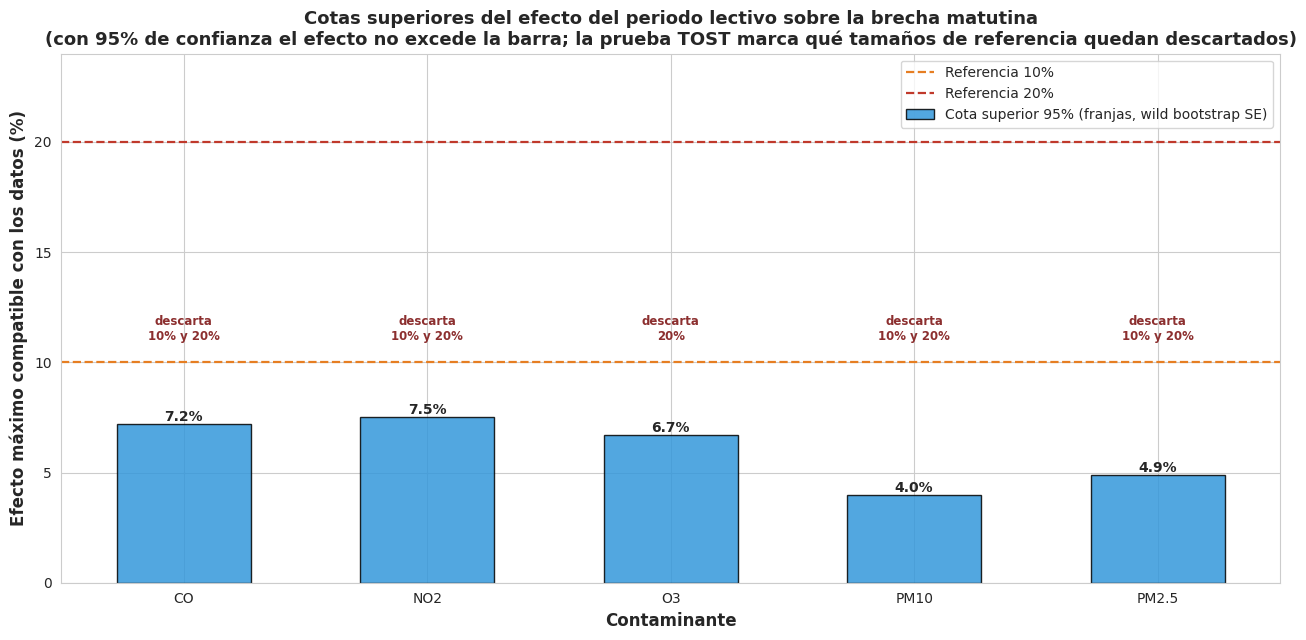

Guardado gráfico en: ../data_processed/graficos_metodos/04_cotas_superiores.png

FINALIZADO


In [4]:
fig, ax = plt.subplots(figsize=(13, 6.5))

eq_franjas = resultados['M2_franjas_hibrido']['equivalencia']
x = np.arange(len(contaminantes))

cotas = [eq_franjas[c]['cota_sup_95_pct'] for c in contaminantes]
bars = ax.bar(x, cotas, 0.55, label='Cota superior 95% (franjas, wild bootstrap SE)',
              color='#3498db', alpha=0.85, edgecolor='black')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
            f'{bar.get_height():.1f}%', ha='center', va='bottom',
            fontsize=10, fontweight='bold')

ax.axhline(10, color='#e67e22', linestyle='--', linewidth=1.6, label='Referencia 10%')
ax.axhline(20, color='#c0392b', linestyle='--', linewidth=1.6, label='Referencia 20%')

for j, c in enumerate(contaminantes):
    marcas = []
    if eq_franjas[c]['tost']['ref_10pct']['rechaza_ese_tamano']:
        marcas.append('10%')
    if eq_franjas[c]['tost']['ref_20pct']['rechaza_ese_tamano']:
        marcas.append('20%')
    if marcas:
        ax.text(j, max(cotas[j] + 2.2, 11), 'descarta\n' + ' y '.join(marcas), ha='center',
                fontsize=8.5, fontweight='bold', color='#8c2f2f')

ax.set_xticks(x)
ax.set_xticklabels(contaminantes)
ax.set_xlabel('Contaminante', fontsize=12, fontweight='bold')
ax.set_ylabel('Efecto máximo compatible con los datos (%)', fontsize=12, fontweight='bold')
ax.set_ylim(0, 24)
ax.set_title('Cotas superiores del efecto del periodo lectivo sobre la brecha matutina\n'
             '(con 95% de confianza el efecto no excede la barra; la prueba TOST marca qué tamaños de referencia quedan descartados)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(graficos_dir / '04_cotas_superiores.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Guardado gráfico en: {graficos_dir / '04_cotas_superiores.png'}")

print('\nFINALIZADO')